### Librerias e importaciones

In [2]:
import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge, Lasso

In [3]:
from src.preprocessing import preprocesamiento_pre_split, preprocesamiento_post_split, onehot_encoding
from src.data_splitting import train_val_split
from src.plots import eda_visualizacion_suvs, plot_precio_segun_antiguedad_km, plot_precio_segun_rango_ant, plot_dispersion_por_marca, plot_grupo_especifico
from src.modelos.xgboost import entrenar_xgboost, entrenar_xgboost_ohe, grid_search
from src.modelos.regresion_lineal import entrenar_regresion_lineal, definir_regularizacion
from src.utils import estandarizar
from src.deteccion_outliers import flagear_outliers_por_grupo, reportar_outliers_por_grupo, ver_outliers, eliminar_outliers_grupo, eliminar_outliers_por_corte
from src.modelos.red_neuronal import buscar_mejor_red_neuronal

In [4]:
#IGNORAR ESTA CELDA
%load_ext autoreload
%autoreload 2

### EDA

**Preprocessing**

In [5]:
data = pd.read_csv('../data/raw/pf_suvs.csv')

In [33]:
print("\n Dataset ALEATORIO")
print(data.sample(5))

print("\n -------- RESUMEN - ESTADISTICOS E INFO -------- \n" )
print("\n DATA INFO")
print(data.info())


 Dataset ALEATORIO
       Unnamed: 0       Marca     Modelo     Año  \
1675         1675        Ford   Ecosport  2013.0   
17618       17618        Ford  Territory  2022.0   
10523       10523        Ford   Ecosport  2017.0   
4522         4522  Volkswagen       Taos  2025.0   
584           584       Volvo       XC60  2012.0   

                            Versión       Color Tipo de combustible  Puertas  \
1675               2.0 Se 143cv 4x2       Negro               Nafta      5.0   
17618                 1.5t Titanium  steel_blue               Nafta      5.0   
10523       1.5 Freestyle 123cv 4x2      Blanco               Nafta      5.0   
4522   1.4 250 Tsi Highline Bi Tono      Blanco               Nafta      5.0   
584                        T5 240CV         NaN               Nafta      5.0   

      Transmisión Motor Tipo de carrocería Con cámara de retroceso Kilómetros  \
1675       Manual   2.0                SUV                     NaN   168402.0   
17618  Automática   1.5 

In [34]:
summary = pd.DataFrame({
    "dtype": data.dtypes,
    "nulos": data.isnull().sum(),
    "unicos": data.nunique()
})
summary

,dtype,nulos,unicos
Unnamed: 0,int64,0,18254
Marca,str,0,47
Modelo,str,0,137
Año,float64,0,40
Versión,str,0,2072
Color,str,389,70
Tipo de combustible,str,0,8
Puertas,float64,0,7
Transmisión,str,15,4
Motor,str,38,271


In [35]:
print("\n DATA DESCRIPCION " )
data.describe()


 DATA DESCRIPCION 


,Unnamed: 0,Año,Puertas,Precio
count,18254.000000,18254.000000,18254.000000,1.825400e+04
mean,9126.500000,2042.796209,18.167306,1.760162e+07
std,5269.620242,3217.260996,891.766121,1.720810e+07
min,0.000000,1981.000000,2.000000,1.110000e+02
25%,4563.250000,2016.000000,5.000000,3.190000e+04
50%,9126.500000,2019.000000,5.000000,1.720000e+07
75%,13689.750000,2024.000000,5.000000,2.995000e+07
max,18253.000000,436694.000000,60252.000000,3.495000e+08


<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
<em>El análisis exploratorio permitió detectar la existencia de valores faltantes en diversas variables descriptivas del vehículo, entre ellas Color, Transmisión, Motor y Con cámara de retroceso. Debido a que estas variables pueden influir significativamente en el valor de mercado de una SUV, se optó por imputar los datos faltantes en lugar de descartar las observaciones correspondientes, preservando así el tamaño de la muestra disponible para entrenamiento.</em>
</p>

<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
<em>Por otra parte, se observó que gran parte de los atributos del dataset se encuentran representados mediante variables categóricas de tipo texto. Dado que los algoritmos de aprendizaje supervisado utilizados trabajan sobre representaciones numéricas, será necesario transformar dichas variables mediante One-Hot Encoding, generando una codificación binaria que permita incorporar esta información al modelo sin introducir relaciones artificiales entre categorías.<em>
</p>

***PREPROCESAMIENTO: Limpieza de datos necesaria para no afectar el entrenamiento del modelo.***

**Justificacion de desiciones tomadas**


<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
1. <code>Unnamed: 0</code> actúa únicamente como identificador de cada publicación y no aporta información relevante para la predicción del precio, por lo que fue eliminada.
Para <code>Tipo de carrocería</code>, el dataset contiene exclusivamente vehículos SUV, por lo que también fue eliminada.</p>

<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
2. <code>Cambio de moneda a USD</code>: Al tratarse de la variable objetivo del problema, fue necesario unificar todas las observaciones en una única moneda (USD) de referencia para garantizar la comparabilidad entre vehículos. Se eliminó la columna ya que no aportaba información.</p>

<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
3. <code>Título</code>: Gran parte de la información contenida en esta columna ya se encuentra representada en otras variables estructuradas del dataset (<code>Marca</code>, <code>Modelo</code>, <code>Motor</code>, <code>Versión</code>, etc.), por lo que se decidió eliminarla para evitar redundancia.</p>

<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
4. <code>Imputación de Puertas</code>: se observaron valores inconsistentes en la variable <code>Puertas</code>. Dado que el conjunto de datos contiene exclusivamente SUVs, se decidió homogeneizar los valores restantes utilizando cinco puertas como valor por defecto.</p>


In [36]:
display(data["Puertas"].value_counts().sort_index())

Puertas
2.0           10
3.0          105
4.0          399
5.0        17731
6.0            3
7.0            2
60252.0        4
Name: count, dtype: int64

<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
5. <code>Motor</code>: presentaba únicamente 38 valores faltantes (menos del 0.3% del dataset). Debido a su baja proporción, se optó por eliminar dichas observaciones en lugar de imputarlas para evitar introducir ruido artificial. A su vez, los datos estaban en <code>str</code> se cambiaron a valor numérico.
</p>

<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
Además la columna contenía formatos muy heterogéneos, combinando cilindrada, tipo de motor y descripciones comerciales (por ejemplo: <em>"2.0 TSI"</em>, <em>"1.5 Turbo"</em>, <em>"Inyección Multipunto"</em> o <em>"Turboalimentado"</em>).</p>

<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
Para preservar la mayor cantidad de información posible se descompuso en varias variables:
<strong>Motor_Litros</strong>, <strong>Motor_Turbo</strong>, <strong>Motor_Multipunto</strong>, <strong>Motor_Diesel</strong>, <strong>Motor_Hibrido</strong>, <strong>Motor_Litros_Faltante</strong>.
</p>
<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
De esta forma se evita descartar observaciones y se conserva información relevante sobre la motorización del vehículo en un formato apto para modelos supervisados.
</p>


In [37]:
nulos_motor = data["Motor"].isna().sum()
total = len(data)

print(f"Nulos en Motor: {nulos_motor}")
print(f"Total de registros: {total}")
print(f"Porcentaje de nulos: {100*nulos_motor/total:.3f}%")

Nulos en Motor: 38
Total de registros: 18254
Porcentaje de nulos: 0.208%


In [38]:
print(data["Motor"].unique().tolist())

['1.5', '2.0 L 230 CV  350 TSI', '1.4', '2.4', '1.5 TURBO', '2.0', '3.6', '1.8', '1.0', '1.3', '1.2 TURBO', '1.2', '1.6', 'Nafta 2.0 (148cv) + Electrico (184.5cv)', '3.0', '2.2', '2.5', '1', '2.5l Hibrida', '2.8', '2.7', 'TURBOALIMENTADO', 'TURBO DIESEL INYECCION', '4.8', '2.9', '1.3T', 'INYECCION MULTI PUNTO', nan, 'diesel', '4.4', '3.0 440HP', '2.0 hurrican 4 272 cv 400nm', '6.4', '5.2', '1.5t', '1.4 TFSI', '2.3', '4.7', '2.0 TDI 140CV', '3.7', '3.2', '1500', '3.8', '1.3 TURBO', '4.5', '3', '2', '2.0 TURBO', '4.0 Nafta', '1.8L', '192 HP', '1.6 Naftero', '5.0', '1.5 TURBO 185 HP', 'P8 (408hp)', '1,3 t 175 cv 270 Nm', '1.6 Turbo', '4.2', '4.0', '1.0 tsi', '1.5 16V', '1.0 200 TSI', '1.8 de 140 hp', '2.0 350TSI', '3.5', '1.3L', '1.3 Turbo', '1.0 TURBO', '1.3 TURBO NAFTA 175CV AT9', 'Motor naftero 1.8 105 CV 161 Nm', '1.0 3 CILINDROS', 'v8 302', '3.3 V6 TD 304cv 700 NM de torque', '1.5 turbo', 'TURBO 2 LITROS', '1.6 MSI Nafta', '1.0T', '6.1', '2500', '2.4L', 'V6 PLUG IN HYBRID 460HP', '2.

In [ ]:
motor_extraido = (data["Motor"].str.extract(r'(\d+[.,]\d+)')[0])

perdidos = data[data["Motor"].notna() & motor_extraido.isna()]

print(len(perdidos))
display(perdidos["Motor"].value_counts().head(10)) 

429


Motor
INYECCION MULTI PUNTO      157
TURBOALIMENTADO             82
1                           67
2                           41
TURBO DIESEL INYECCION      10
Turbo 140 CV                 4
1600                         3
1500                         2
192 HP                       2
V6 PLUG IN HYBRID 460HP      2
Name: count, dtype: int64

<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
En los casos donde la cilindrada no pudo recuperarse, se incorporó la variable indicadora <strong>Motor_Litros_Faltante</strong>, permitiendo al modelo distinguir entre motores con cilindrada conocida y desconocida.

<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
6. <code>Kilómetros</code>: Se transformó a valor numérico para garantizar un tratamiento consistente. Además se crea el feature <code>0km</code> que indica si el vehículo es nuevo o usado. Posteriormente se incorporó <code>Log_Km</code> para reducir la asimetría observada en la distribución original.
</p>

<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
7. <code>Descripción</code>: se aplicó <strong>TF-IDF</strong> (<em>Term Frequency - Inverse Document Frequency</em>) para vectorizar las descripciones, asignando mayor peso a las palabras relevantes y menor a las más frecuentes en todo el dataset. Dado que esto genera un vector de alta dimensionalidad, se aplicó <strong>SVD</strong> para reducir la dimensionalidad a 20 componentes, preservando la mayor parte de la información semántica.
</p>

<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
8. <code>Marca</code>: Se unificaron las muestras para evitar duplicados y/o reconocimiento erróneo de una marca.
A su vez, se combinó <code>Marca</code> y <code>Modelo</code> en una sola feature <code>Marca_Modelo</code>.
</p>


In [40]:
print(data["Marca"].unique().tolist())

['Ford', 'Volkswagen', 'Jeep', 'BAIC', 'Kia', 'Hyundai', 'Porsche', 'Peugeot', 'Fiat', 'Chevrolet', 'Citroën', 'BMW', 'Audi', 'Honda', 'Nissan', 'Mercedes-Benz', 'Renault', 'Suzuki', 'Toyota', 'D.S.', 'Chery', 'Daihatsu', 'SsangYong', 'Dodge', 'JAC', 'Land Rover', 'Alfa Romeo', 'Haval', 'Volvo', 'Lifan', 'Mini', 'D·S', 'Mitsubishi', 'Range Rover', 'Hiunday', 'Jetour', 'GWM', 'KAIYI', 'Lexus', 'Isuzu', 'Rrenault', 'Subaru', 'Jetur', 'DS AUTOMOBILES', 'hiunday', 'Jaguar', 'Vol']


8. `Año`: Considerando que se tiene 1 valor extremo, claro outlier o error de carga, se elimina la muestra ya que no aporta informacion ni se pierde al no tenerla.

In [41]:
display(pd.DataFrame(data['Año'].describe()))

,Año
count,18254.000000
mean,2042.796209
std,3217.260996
min,1981.000000
25%,2016.000000
50%,2019.000000
75%,2024.000000
max,436694.000000


In [42]:
print((data["Año"] > 2025).sum()) 
print(data[data["Año"] > 2025]["Año"].unique()) 

1
[436694.]


<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
9. <code>Color</code>: considerando que se tienen colores definidos en mayuscula y minuscula, femenino y masculino, se unifican todas las muestras a minuscula masculino. A la vez, al haber pocas muestras de colores especificos, tales como 'gris titane' (1 sola muestra) o 'gris artense', el modelo no aprendera de estas, por lo que resulta conveniente unificarlas dentro de los colores genericos (en el caso de los ejemplos, dentro de 'gris). Asi se redujo la cardinalidad sin perder informacion relevante.
</p>

In [43]:
print(data["Color"].value_counts().to_string())

Color
Gris                             5468
Blanco                           4809
Negro                            2825
Plateado                         1427
Azul                             1121
Rojo                             1118
Marrón                            253
Dorado                            190
Verde                             135
Beige                             125
Celeste                            93
Naranja                            73
Gris oscuro                        43
Violeta                            33
Bordó                              29
Amarillo                           24
Rosa                                8
Plata                               7
Otro                                6
Blanca                              4
Acero                               4
BLANCA                              3
Café                                3
Negra                               3
Gris plata                          3
steel_blue                          2
GRIS S

<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
10. <code>Versión</code>: se agruparon las versiones en tres categroias, Version_Base, Version_Intermedia  y Version_Premium. Se clasificó utilizanod palabras clave frecuentes asociadas al nivel del equipamiento del veehículo.
</p>

<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
11. <code>Con Camara de retroceso</code>: tiene una gran cantidad de valores faltantes. Antes de realizar cualquier imputación estadística, se intentó recuperar esta información buscando referencias a cámaras o sensores de estacionamiento dentro de la descripción de cada vehículo. Cuando no fue posible inferir la presencia de la característica, el registro fue etiquetado como "Desconocido", permitiendo conservar la observación sin introducir supuestos adicionales.
</p>

In [6]:
data_pre = preprocesamiento_pre_split(data)
print('Tamaño final del dataset -> ', data_pre.shape)

Tamaño final del dataset ->  (18205, 21)


**NUEVO DATASET**

In [45]:
print("\n Dataset NUEVO, ALEATORIO")
print(data_pre.sample(5))

print("\n -------- RESUMEN - ESTADISTICOS E INFO -------- \n" )
print("\n data_pre INFO")
print(data_pre.info())
print("\n data_pre DESCRIPCION " )
print(data_pre.describe())


 Dataset NUEVO, ALEATORIO
          Año     Color Tipo de combustible  Puertas Transmisión  \
16550  2025.0      gris               Nafta      5.0  Automática   
8861   2019.0    blanco               Nafta      5.0      Manual   
1618   2024.0      gris               Nafta      5.0      Manual   
6590   2025.0      gris               Nafta      5.0  Automática   
3368   2025.0  plateado               Nafta      5.0  Automática   

      Con cámara de retroceso  Kilómetros        Precio  \
16550                      Sí         0.0  39232.411087   
8861              Desconocido    100000.0  28997.867804   
1618              Desconocido      1111.0  27292.110874   
6590                       Sí         0.0  44900.000000   
3368              Desconocido         0.0  31769.722814   

                                             Descripción Tipo de vendedor  \
16550  // BIENVENIDOS A AUTODRIVE CONCESIONARIO OFICI...           tienda   
8861   Es año 2018,  está publicada como 2019 por que..

In [46]:
summary = pd.DataFrame({
    "dtype": data_pre.dtypes,
    "nulos": data_pre.isnull().sum(),
    "unicos": data_pre.nunique()
})
summary

,dtype,nulos,unicos
Año,float64,0,38
Color,str,379,16
Tipo de combustible,str,0,8
Puertas,float64,0,2
Transmisión,str,11,4
Con cámara de retroceso,str,0,3
Kilómetros,float64,431,2120
Precio,float64,0,2909
Descripción,str,0,12104
Tipo de vendedor,str,0,3


#### **Deteccion de outliers**

In [7]:
df_outliers = data_pre.copy()

In [8]:
df_outliers = flagear_outliers_por_grupo(df_outliers, grupo_col = "Marca_Modelo", col = "Precio", k = 1.5, min_registros = 10)

[Precio] Outliers detectados: 544 (2.99%)
Grupos chicos no filtrados (<10 registros): 49


In [ ]:
resumen_outliers = reportar_outliers_por_grupo(df_outliers, grupo_col = "Marca_Modelo", col = "Precio", top_n = 20)
display(resumen_outliers.round(2))

,n_outliers,precio_min,precio_max,precio_mediana
Marca_Modelo,,,,
Renault_Duster,89,111.00,45492.54,27742.42
Fiat_Pulse,40,1108.74,13219.62,10234.54
BAIC_X55,36,17900.00,45700.00,44150.00
Hyundai_Tucson,34,48900.00,58900.00,58000.00
Honda_HR-V,26,6500.00,40912.58,38250.00
BMW_X6,24,135000.00,268900.00,179999.50
BMW_X1,23,65900.00,89900.00,84000.00
Citroën_C3 Aircross,20,10157.78,18763.33,13816.63
Honda_CR-V,17,35000.00,75275.00,54000.00


In [ ]:
#Ejemplos
ver_outliers(df_outliers, col = "Precio", n = 20)

,Marca_Modelo,Precio,Año,Kilómetros
6616,Land Rover_Range Rover Sport,610000.000000,2024.0,0.0
6336,Porsche_Cayenne,345000.000000,2022.0,14000.0
17423,Land Rover_Range Rover Sport,315000.000000,2025.0,0.0
2820,Land Rover_Range Rover Sport,315000.000000,2025.0,0.0
11199,Volkswagen_Nivus,298081.023454,2024.0,0.0
15900,BMW_X6,268900.000000,2025.0,0.0
10264,Porsche_Macan,268000.000000,2025.0,0.0
9638,BMW_X6,264900.000000,2025.0,0.0
11510,Porsche_Cayenne,259000.000000,2025.0,0.0
9883,Porsche_Cayenne,258000.000000,2025.0,0.0


Land Rover_Range Rover Sport — 18 registros
Q1=34,250.00
Q3=123,425.00
IQR=89,175.00
Rango válido: [-99,512.50, 257,187.50]
Outliers detectados: 3


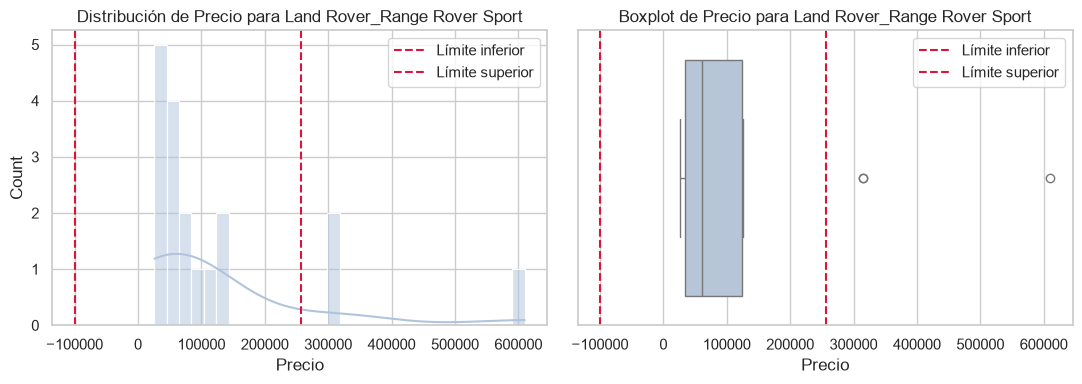

Renault_Duster — 1047 registros
Q1=11,940.30
Q3=17,304.90
IQR=5,364.61
Rango válido: [3,893.39, 25,351.81]
Outliers detectados: 89


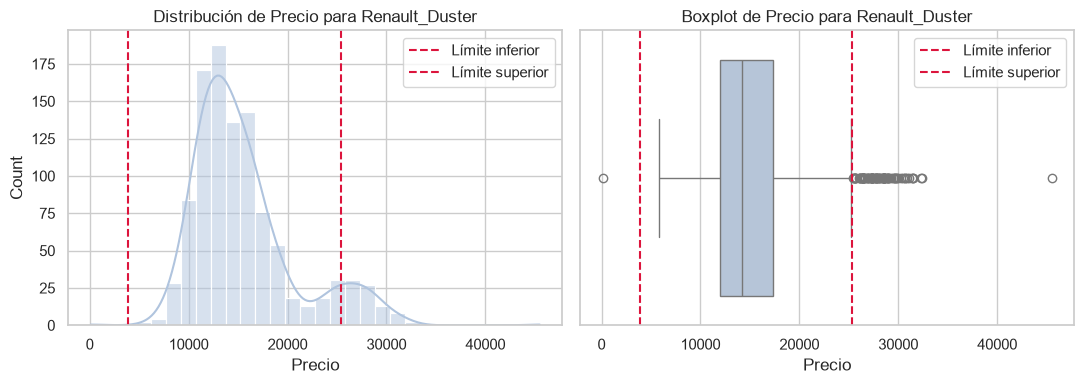

Jeep_Wrangler — 109 registros
Q1=38,500.00
Q3=90,000.00
IQR=51,500.00
Rango válido: [-38,750.00, 167,250.00]
Outliers detectados: 0


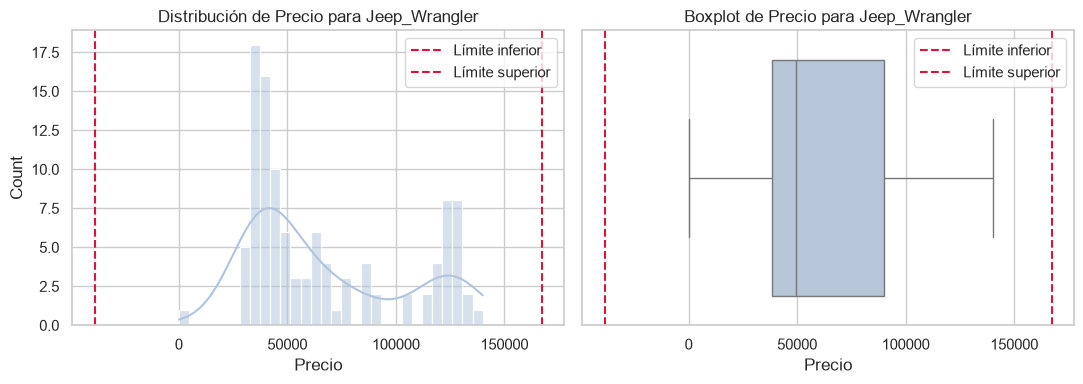

In [ ]:
#Ejemplos especificos de Marca_Modelo con outliers
vista_outliers_marca = plot_grupo_especifico(df_outliers, grupo = "Land Rover_Range Rover Sport", k = 1.5)
vista_outliers_marca_= plot_grupo_especifico(df_outliers, grupo = "Renault_Duster", k = 1.5)
vista_outliers_marca_= plot_grupo_especifico(df_outliers, grupo = "Jeep_Wrangler", k = 1.5)

<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
Lo que se logra notar es que hay precios < 5000 USD los cuales el IQR no logra detectar, por lo que se opta por eliminar estos casos para evitar outliers por Marca_Modelo.
</p>

In [53]:
len(df_outliers[df_outliers["Precio"] <= 5000])

25

##### Outliers en 'Kilometros'

In [ ]:
display(data_pre[data_pre["Kilómetros"] > 500000]
    [["Marca_Modelo", "Precio", "Año", "Kilómetros"]]
    .sort_values("Kilómetros", ascending=False)
)

,Marca_Modelo,Precio,Año,Kilómetros
7614,Chevrolet_Blazer,7931.769723,2000.0,9999999.0
14106,Toyota_Hilux SW4,21748.400853,2009.0,1700000.0
16287,Nissan_Kicks,23027.718550,2020.0,1111111.0
14201,Peugeot_2008,18336.886994,2025.0,1111111.0
6479,Renault_Duster,7500.000000,2013.0,1111111.0
6109,Renault_Duster,12963.752665,2013.0,1111111.0
7156,Ford_Bronco,45000.000000,1981.0,1111111.0
11008,Suzuki_Jimny,11000.000000,1999.0,1111111.0
16688,Nissan_Kicks,23027.718550,2020.0,1111111.0
6118,Renault_Duster,14000.000000,2018.0,1111111.0


#### Creacion del dataset sin outliers

In [ ]:
#Eliminar las muestras cuyo precio queda fuera del rango iqr correspondiente a su su marca_modelo
data_pre_sin_outliers= eliminar_outliers_grupo(df_outliers)
#Eliminar casos donde km >= 500000 
data_pre_sin_outliers = data_pre_sin_outliers [data_pre_sin_outliers["Kilómetros"] <= 500000].copy()

print("Original:", data_pre.shape)
print("IQR + Km limpio:", data_pre_sin_outliers.shape)

#Eliminar precio < 5000 USD
data_pre_final = eliminar_outliers_por_corte(
    data_pre_sin_outliers,
    precio_min=5000
)

print("\nIQR + Km + precio > 5000:", data_pre_final.shape)

Registros antes: 18205
Registros después: 17661
Eliminados: 544 (2.99%)
Original: (18205, 21)
IQR + KM limpio: (17224, 21)
Eliminados: 19 (0.11%)
IQR + KM + > 5000: (17205, 21)


In [11]:
data_pre_final.to_csv("../data/processed/data_pre.csv", index=False)

**VISUALIZACION DEL EDA HASTA AHORA**

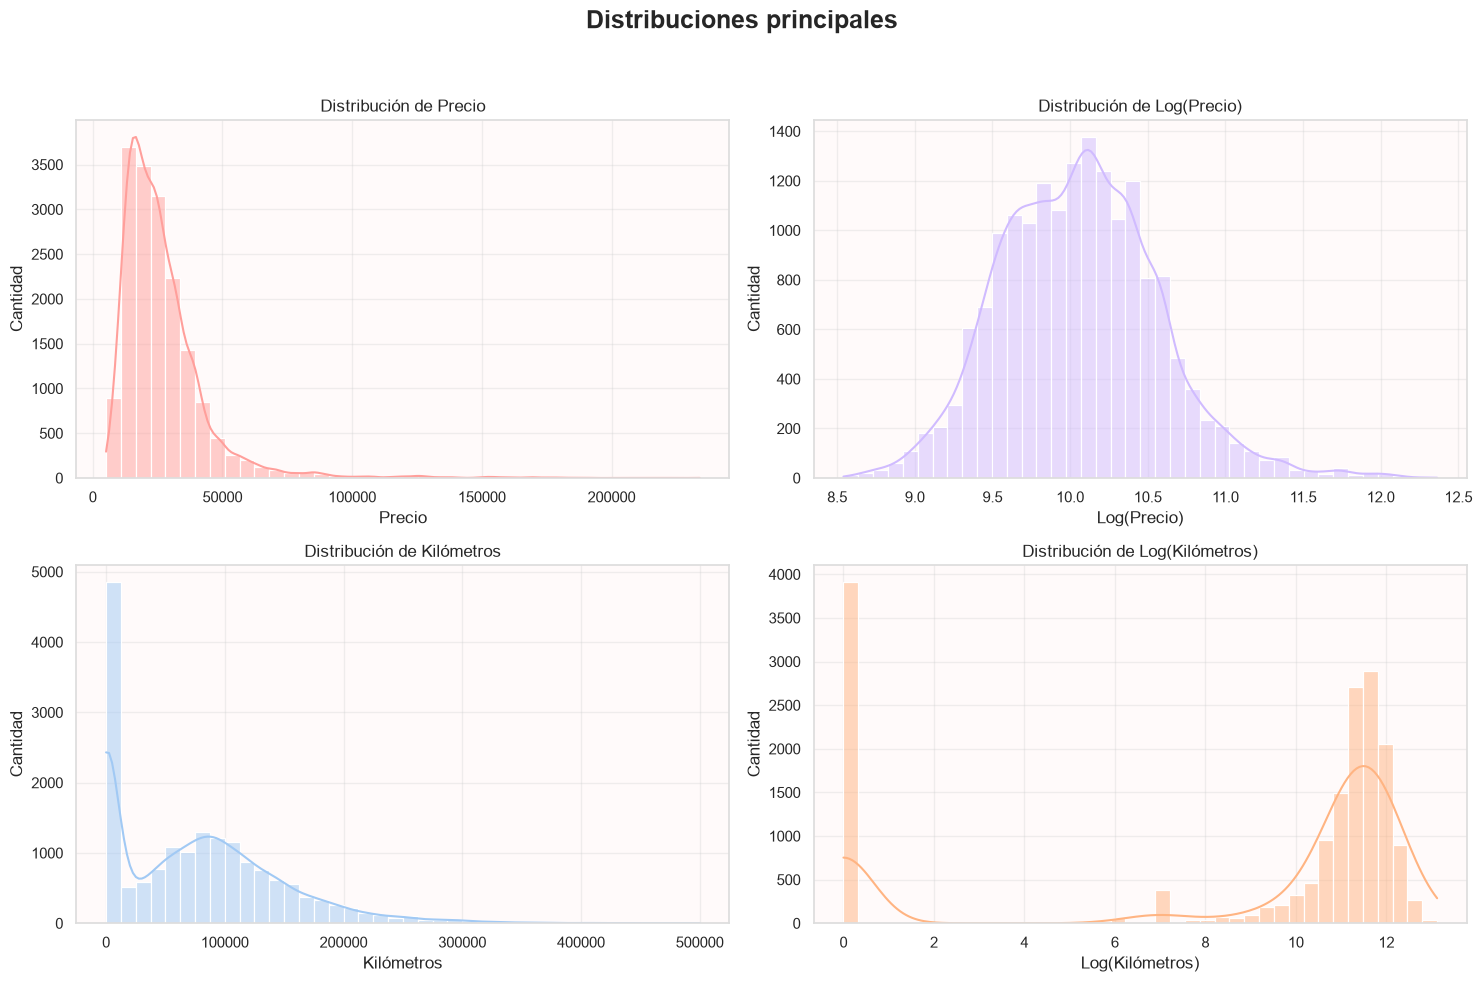

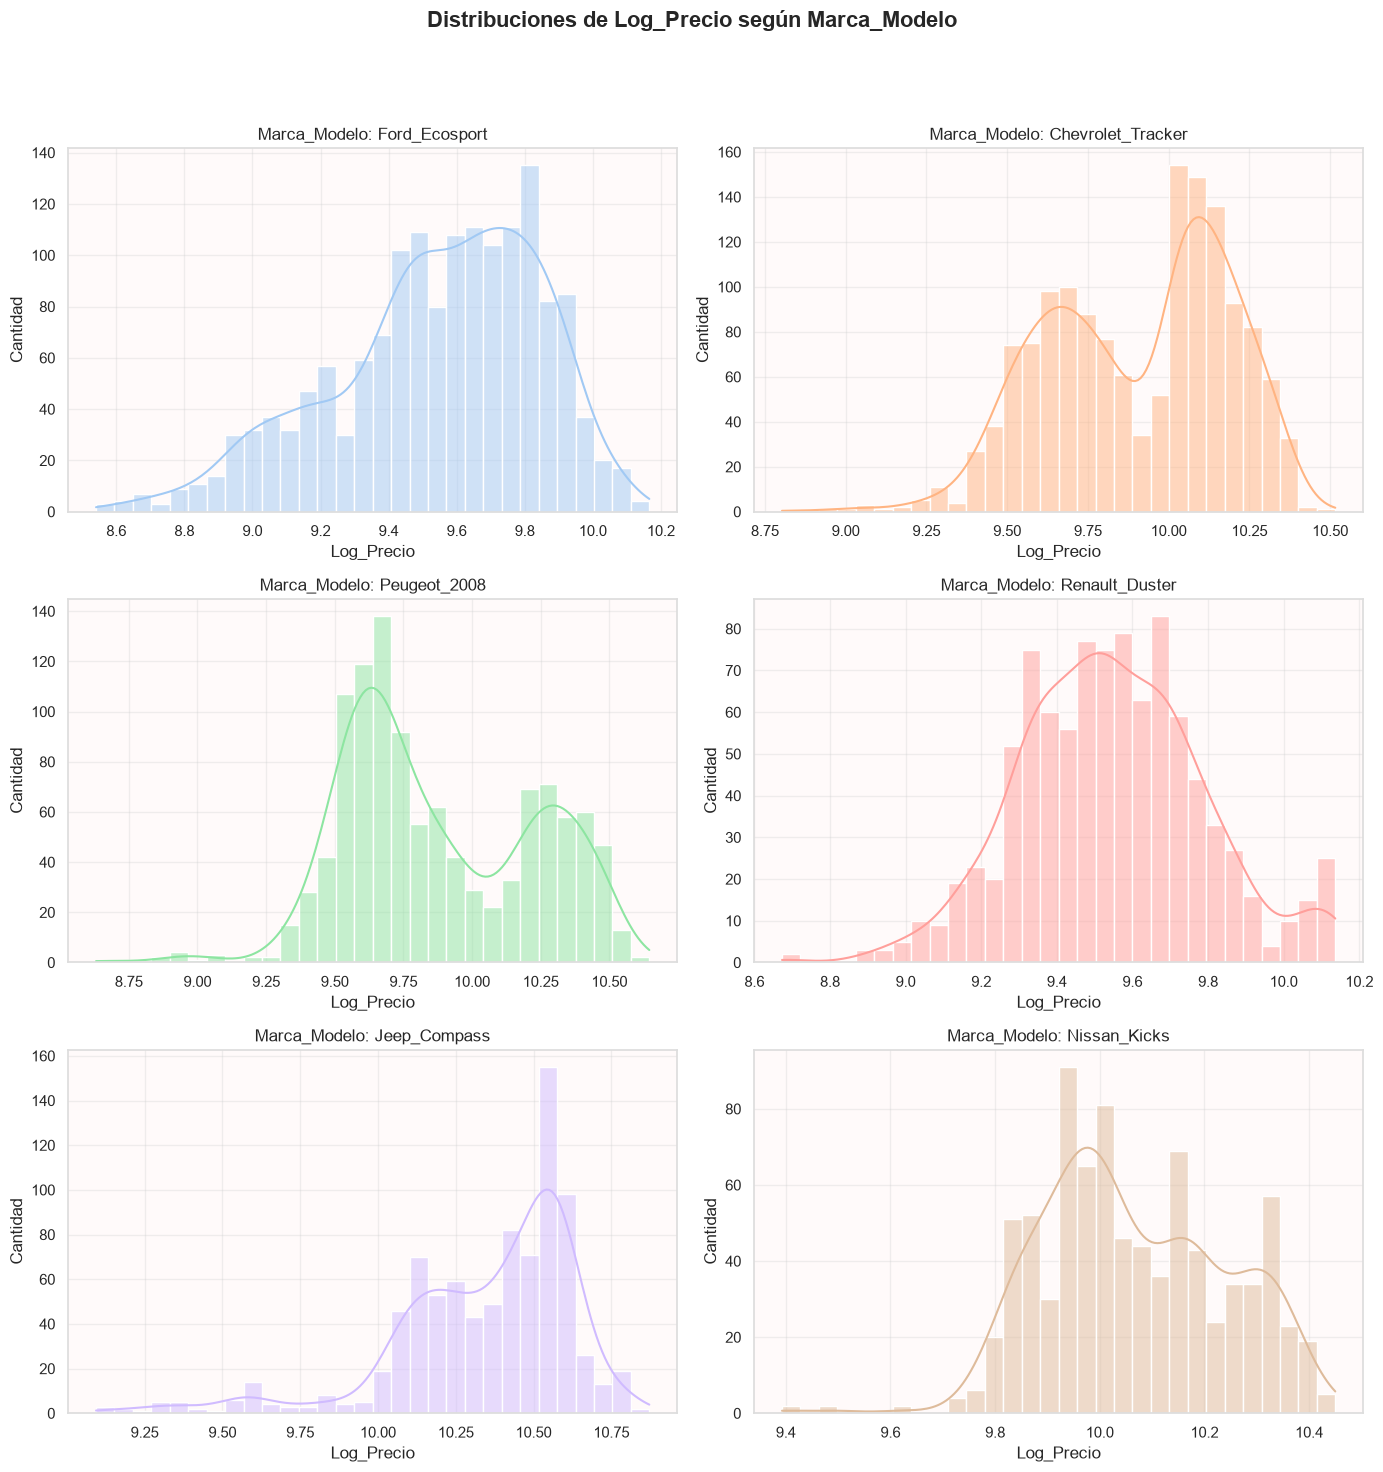

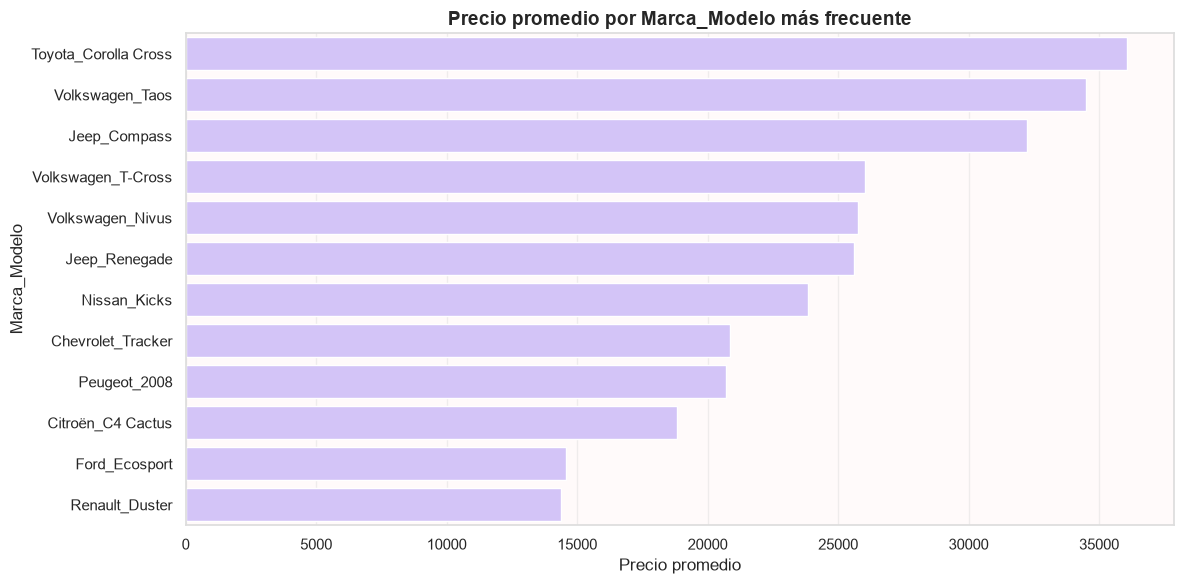

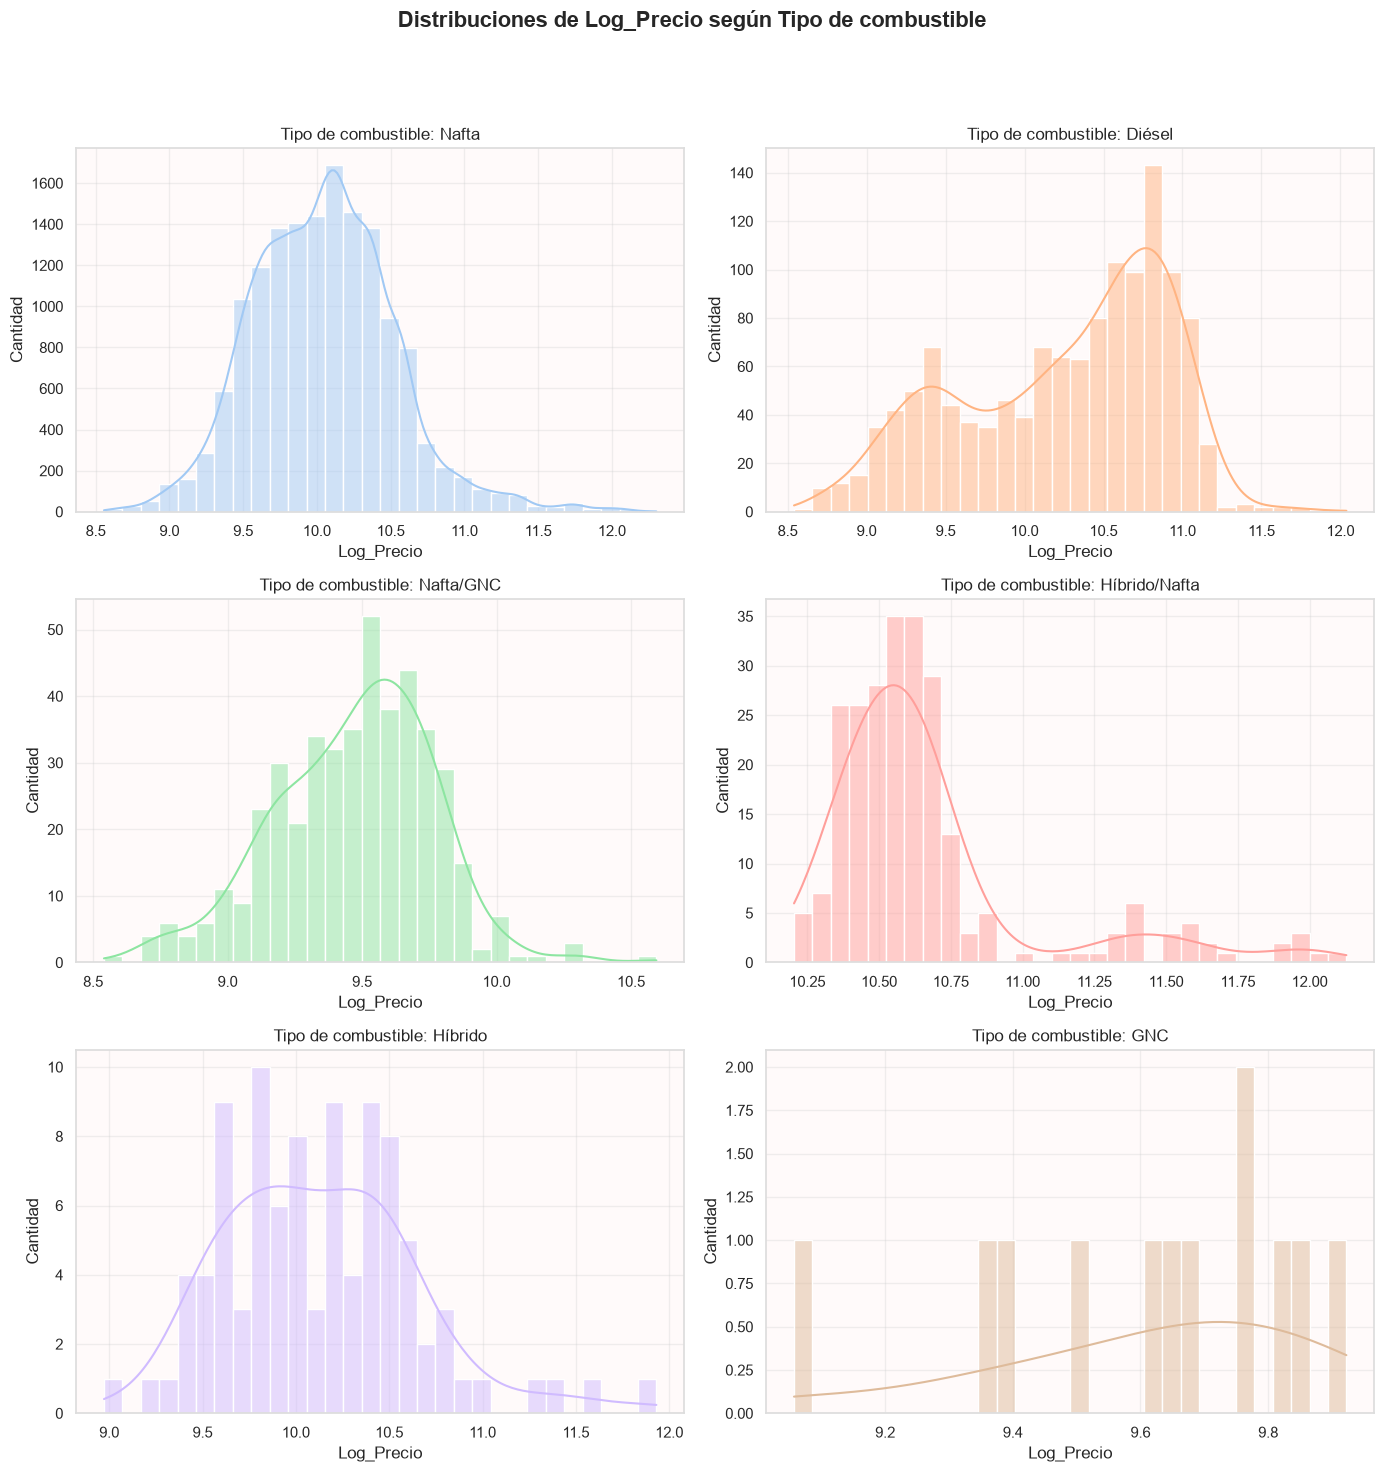

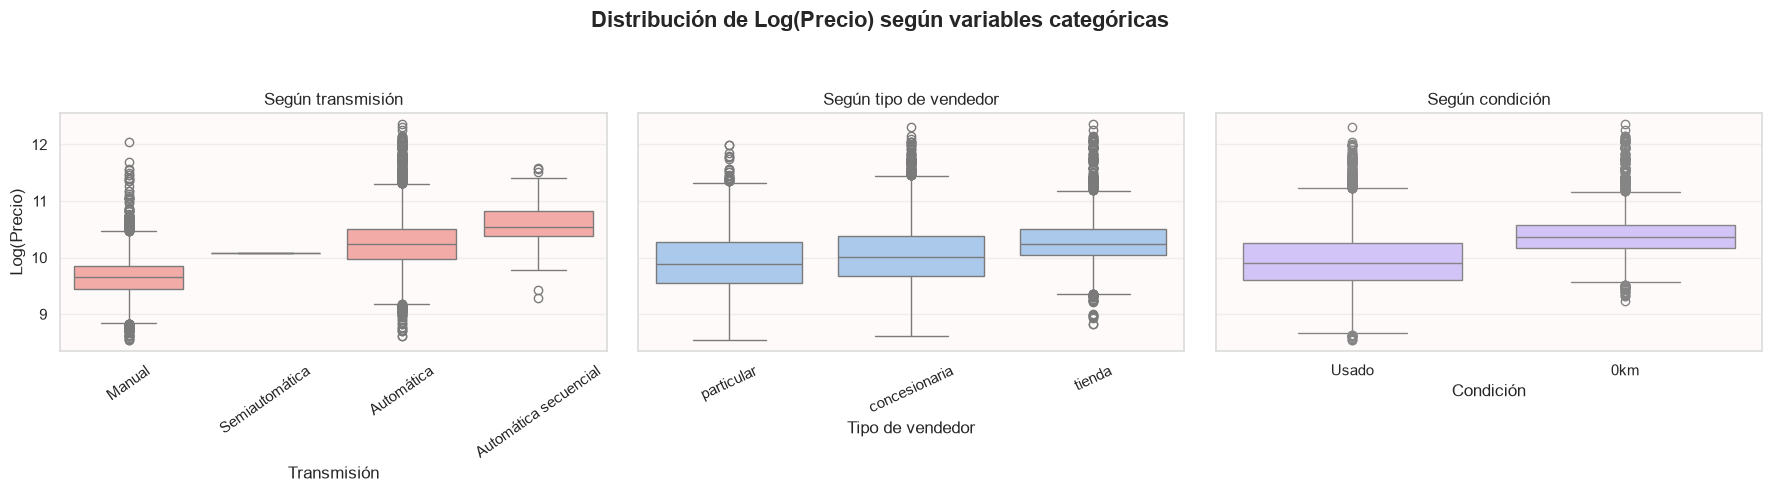

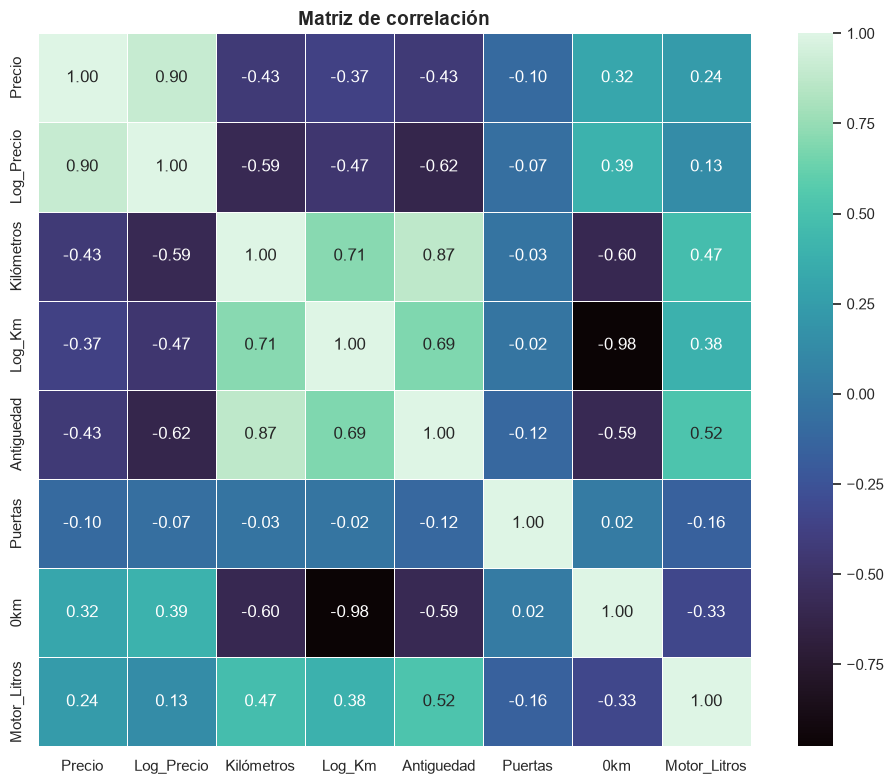

In [ ]:
#Plots
eda_visualizacion_suvs(data_pre_final) 

<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
<em>Se observan diferencias de precio según el modelo, el combustible y la condición del vehículo. Además, tanto el kilometraje como la antigüedad presentan una relación negativa con el precio. Las transformaciones logarítmicas permiten visualizar mejor estas relaciones al reducir la asimetría de las distribuciones originales.</em>
</p>

<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
Para terminar con el <em><strong>preprocesamiento de datos</strong></em>, se aplica el split para poder obtener la moda calculada sobre el conjunto de train, y asi poder completar los valores faltantes de las features "Color", "Transmision", "Camara", "Kilómetros", "Motor_Litros" evitando el data leakage.
</p>

In [12]:
nulos = data_pre_final.isnull().sum()

if (nulos > 0).any():
    print("Columnas con NaN:")
    print(nulos[nulos > 0])
else:
    print("No quedan NaN en el dataset")

Columnas con NaN:
Color           360
Transmisión      10
Motor_Litros    392
dtype: int64


<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
11. <strong>Imputaciones realizadas después del split</strong>: todas las imputaciones basadas en estadísticas (moda o mediana) fueron calculadas exclusivamente sobre el conjunto de entrenamiento y posteriormente aplicadas al conjunto de validación, evitando data leakage.
</p>
<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
- <strong>Color</strong>: los valores faltantes se completaron utilizando la moda del color para cada vehículo (`Marca_Modelo`). Si un modelo no poseía suficientes observaciones, se utilizó la moda global del conjunto de entrenamiento.
</p>
<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
- <strong>Transmisión</strong>: debido a la baja cantidad de valores faltantes, se utilizó un imputador KNN entrenado sobre el conjunto de entrenamiento. La imputación se realizó considerando vehículos con características similares y posteriormente se reconstruyó la categoría original.
</p>
<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
- <strong>Kilómetros</strong>: los valores faltantes se completaron utilizando la mediana del kilometraje correspondiente al año del vehículo. En caso de no existir suficientes observaciones para un determinado año, se utilizó la mediana global del conjunto de entrenamiento.
</p>
<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
- <strong>Motor_Litros</strong>: cuando no fue posible recuperar la cilindrada a partir de la descripción original del motor, el valor faltante se imputó utilizando la mediana calculada sobre el conjunto de entrenamiento. Adicionalmente, se conservó la variable indicadora `Motor_Litros_Faltante` para que el modelo pudiera distinguir los registros originalmente incompletos.
</p>

In [13]:
train, val = train_val_split(data_pre_final)

Tamaño conjunto de entrenamiento -> (13764, 21), 
Tamaño conjunto de validación -> (3441, 21)


In [ ]:
#Preprocessing post split usando los parametros del entrenamiento
X_train, X_val = preprocesamiento_post_split(train, val)

In [ ]:
#One-Hot Encoding sobre las columnas con baja cardinalidad
columnas_oh = ["Marca_Modelo","Color",'Tipo de combustible', 'Tipo de vendedor', 'Transmisión', 'Con cámara de retroceso']
X_train_final, X_val_final = onehot_encoding(X_train, X_val, columnas_oh)

In [16]:
print('Tamaño train final -> ', X_train_final.shape)
print('Tamaño val final -> ', X_val_final.shape)

Tamaño train final ->  (13764, 215)
Tamaño val final ->  (3441, 215)


In [ ]:
print('Final del preprocesamiento sobre entrenamiento')
summary = pd.DataFrame({
    "dtype": X_train_final.dtypes,
    "nulos": X_train_final.isnull().sum(),
    "unicos": X_train_final.nunique()
})
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

display(summary)

Final del preprocesamiento sobre Entrenamiento


,dtype,nulos,unicos
Año,float64,0,37
Puertas,float64,0,2
Kilómetros,float64,0,1799
Precio,float64,0,2454
0km,int64,0,2
Motor_Litros,float64,0,39
Motor_Turbo,int64,0,2
Motor_Multipunto,int64,0,2
Motor_Diesel,int64,0,2
Motor_Hibrido,int64,0,2


In [ ]:
print('Final del preprocesamiento sobre validación')
summary_ = pd.DataFrame({
    "dtype": X_val_final.dtypes,
    "nulos": X_val_final.isnull().sum(),
    "unicos": X_val_final.nunique()
})

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
display(summary_)

In [ ]:
#Cargar el set de entrenamiento y validación a csv para observar los cambios
X_train_final.to_csv("../data/processed/X_train_EDA.csv", index=False)
X_val_final.to_csv("../data/processed/X_val_EDA.csv", index=False)

### **MODELOS**

<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
Para el desarrollo de los modelos, optamos por analizar 2 casos: considerando el TF-IDF sobre la variable de Descripcion y, el extremo opuesto, eliminando esta columna. Esto se realizo con el objetivo de analizar la incidencia de este feature en la prediccion de los precios.
</p>

In [ ]:
#Sin variables categóricas, considerando OHE
X_train_ohe = X_train_final.drop(columns = ['Precio'])
y_train_ohe = X_train_final['Precio']

X_val_ohe = X_val_final.drop(columns = ['Precio'])
y_val_ohe = X_val_final['Precio']

In [ ]:
#Estandarización
#Con 'Descripción'
X_train_array, X_val_array, _, _ = estandarizar(X_train_ohe.values, X_val_ohe.values)
X_train_ohe_estandarizado = pd.DataFrame(X_train_array, columns = X_train_ohe.columns)
X_val_ohe_estandarizado = pd.DataFrame(X_val_array, columns = X_val_ohe.columns)

#Sin 'Descripción'
columnas = [col for col in X_train_ohe_estandarizado.columns if col.startswith('Descripcion_')]
X_train_no_desc = X_train_ohe_estandarizado.drop(columns = columnas)
X_val_no_desc = X_val_ohe_estandarizado.drop(columns = [col for col in X_val_ohe_estandarizado.columns if col.startswith('Descripcion_')])

#### **Regresion Lineal** 

##### **Regresion sin regularizacion (modelo baseline)**

In [ ]:
#Con TF-IDF sobre 'Descripción'
modelo_rl_base, predicciones_rl_base, rmse_rl_base, mae_rl_base, r2_rl_base = entrenar_regresion_lineal(X_train_ohe_estandarizado, y_train_ohe, X_val_ohe_estandarizado, y_val_ohe)

#Sin TF-IDF sobre 'Descripción'
modelo_rl_base_no_desc, predicciones_rl_base_no_desc, rmse_rl_base_no_desc, mae_rl_base_no_desc, r2_rl_base_no_desc = entrenar_regresion_lineal(X_train_no_desc, y_train_ohe, X_val_no_desc, y_val_ohe)

In [ ]:
print(f'Con TF-IDF sobre Descripcion -> RMSE (USD) = {rmse_rl_base}')
print(f'Sin TF-IDF sobre Descripcion -> RMSE (USD) = {rmse_rl_base_no_desc}')

In [ ]:
#Regresion lineal + regularizacion
modelo_rl, predicciones_rl, _, _, _ = entrenar_regresion_lineal(X_train_ohe_estandarizado, y_train_ohe, X_val_ohe_estandarizado, y_val_ohe)

#Busqueda de lambdas para regularizacion
print(f'Busqueda parametro de regularizacion')
lambdas = [0.1, 0.5, 1.0, 10.0]

#Con TF-IDF sobre 'Descripción'
resultados_tfidf = definir_regularizacion(X_train_ohe_estandarizado, y_train_ohe, X_val_ohe_estandarizado, y_val_ohe, lambdas)
print(f"Con TF-IDF sobre Descripcion -> mejor R²: {resultados_tfidf['R2'].max():.4f}")

#Sin TF-IDF sobre 'Descripción'
resultados_no_desc = definir_regularizacion(X_train_no_desc, y_train_ohe, X_val_no_desc, y_val_ohe, lambdas)
print(f"SIN TF-IDF sobre Descripcion -> mejor R²: {resultados_no_desc['R2'].max():.4f}")

Busqueda parametro de regularizacion
Con TF-IDF sobre Descripcion
Mejor R²: 0.8503
SIN TF-IDF sobre Descripcion
Mejor R²: 0.8460


In [ ]:
print('Resultados ordenados por R² considerando TF-IDF sobre Descripción')
display(resultados_tfidf.iloc[:5])
print('Resultados ordenados por R² sin considerar TF-IDF sobre Descripción')
display(resultados_no_desc[:5])

Resultados considerando TF-IDF sobre Descripción


,Modelo,Lambda,RMSE,MAE,R2
5,Lasso,1.0,6260.408140,3744.407257,0.850344
3,Lasso,0.5,6260.486509,3745.898864,0.850340
1,Lasso,0.1,6260.597131,3747.142136,0.850335
0,Ridge,0.1,6261.759016,3747.938061,0.850279
2,Ridge,0.5,6261.802778,3747.792713,0.850277
4,Ridge,1.0,6261.858543,3747.615060,0.850275
6,Ridge,10.0,6262.995585,3744.776939,0.850220
7,Lasso,10.0,6266.431707,3723.643578,0.850056


Resultados sin considerar TF-IDF sobre Descripción


,Modelo,Lambda,RMSE,MAE,R2
5,Lasso,1.0,6349.772910,3752.715017,0.846041
3,Lasso,0.5,6349.904806,3754.328408,0.846035
1,Lasso,0.1,6350.005475,3755.570736,0.846030
0,Ridge,0.1,6350.954445,3756.352051,0.845984
2,Ridge,0.5,6351.000887,3756.209359,0.845981
4,Ridge,1.0,6351.059883,3756.032487,0.845979
6,Ridge,10.0,6352.236086,3753.030290,0.845921
7,Lasso,10.0,6356.842217,3732.399336,0.845698


In [ ]:
mejor_tfidf = resultados_tfidf.iloc[0]
mejor_no_desc = resultados_no_desc.iloc[0]

mejor_rl_config = mejor_tfidf if mejor_tfidf['R2'] > mejor_no_desc['R2'] else mejor_no_desc

mejor_X_train = X_train_ohe_estandarizado if mejor_tfidf['R2'] > mejor_no_desc['R2'] else X_train_no_desc
mejor_X_val = X_val_ohe_estandarizado if mejor_tfidf['R2'] > mejor_no_desc['R2'] else X_val_no_desc
mejor_y_train = y_train_ohe
mejor_y_val = y_val_ohe

if mejor_rl['Modelo'] == 'Ridge':
    mejor_rl = Ridge(alpha = mejor_rl['Lambda'], solver = 'svd')
else:
    mejor_rl = Lasso(alpha = mejor_rl['Lambda'], max_iter = 50000)

if mejor_no_desc['Modelo'] == 'Ridge':
    rl_no_desc = Ridge(alpha=mejor_no_desc['Lambda'], solver='svd')
else:
    rl_no_desc = Lasso(alpha=mejor_no_desc['Lambda'], max_iter=50000)


modelo_rl_final, predicciones_rl_final, rmse_rl_final, mae_rl_final, r2_rl_final = entrenar_regresion_lineal(mejor_X_train, mejor_y_train, mejor_X_val, mejor_y_val, modelo = mejor_rl)
_, _, rmse_rl_no_desc_final, mae_rl_no_desc_final, r2_rl_no_desc_final = entrenar_regresion_lineal(X_train_no_desc, y_train_ohe, X_val_no_desc, y_val_ohe, modelo = rl_no_desc)

if mejor_rl['R2'] == mejor_tfidf['R2']:
    coefs = pd.Series(modelo_rl_final.coef_, index = mejor_X_train.columns)
    desc_coefs = coefs[[c for c in coefs.index if c.startswith("Descripcion_")]]
    print(desc_coefs.sort_values(key = abs, ascending=False).to_string(dtype = False))

Descripcion_3     1003.016045
Descripcion_0     -497.740912
Descripcion_1      420.262847
Descripcion_2      323.816058
Descripcion_10     293.628509
Descripcion_17    -287.416521
Descripcion_5      235.523840
Descripcion_11     201.538678
Descripcion_4     -198.467694
Descripcion_12    -143.357710
Descripcion_15    -116.929984
Descripcion_6      107.965583
Descripcion_8       89.994299
Descripcion_18     -78.689900
Descripcion_13      58.724145
Descripcion_14     -50.636440
Descripcion_16     -22.607226
Descripcion_7      -13.192295
Descripcion_9       11.041581
Descripcion_19      -5.950886
dtype: float64


#### **XGBoost**

In [72]:
grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [4,6,8],
    'learning_rate': [0.05, 0.1, 0.5] 
    }

<p style="text-align: justify; text-justify: inter-word; font-size: 16px;">
Dado que XGBoost soporta de manera nativa variables categoricas, estableciendo <code>enable_categorical = True</code>, se desarrollaron 2 arboles: el primero considerando esta opcion, mientras que el segundo utilizo el dataset donde a las variables categoricas se les aplico One-Hot Encoding.

A su vez, los arboles son invariantes a la escala de los features, razon por la cual no se estandarizan.
</p>

In [ ]:
#DATASETS CON FEATURES CATEGORICAS
#Con variables categoricas
X_train_xgboost = X_train.drop(columns = ['Precio'])
y_train_xgboost = train['Precio']

X_val_xgboost = X_val.drop(columns = ['Precio'])
y_val_xgboost = val['Precio']

#Sin TF-IDF sobre 'Descripción'
X_train_xgboost_no_desc = X_train_xgboost.drop(columns = columnas)
X_val_xgboost_no_desc = X_val_xgboost.drop(columns = columnas)

Con TF-IDF sobre Descripcion

Sin TF-IDF sobre Descripcion


In [74]:
#Con TF-IDF - Grid search categorico
resultados_gs_categorico = grid_search(X_train_xgboost, y_train_xgboost, n_estimators_list = grid['n_estimators'], max_depth_list = grid['max_depth'], learning_rate_list = grid['learning_rate'])

#Sin TF-IDF - Grid search categorico
resultados_gs_categorico_no_desc = grid_search(X_train_xgboost_no_desc, y_train_xgboost, n_estimators_list = grid['n_estimators'], max_depth_list = grid['max_depth'], learning_rate_list = grid['learning_rate'])

In [ ]:
#Con TF-IDF - Grid search OHE
resultados_gs_ohe = grid_search(X_train_ohe, y_train_xgboost, n_estimators_list = grid['n_estimators'], max_depth_list = grid['max_depth'], learning_rate_list = grid['learning_rate'], categorico = False)

#Sin TF-IDF - Grid search OHE
X_train_ohe_no_desc = X_train_ohe.drop(columns = columnas)
X_val_ohe_no_desc = X_val_ohe.drop(columns = columnas)
resultados_gs_ohe_no_desc = grid_search(X_train_ohe_no_desc, y_train_xgboost, n_estimators_list = grid['n_estimators'], max_depth_list = grid['max_depth'], learning_rate_list = grid['learning_rate'], categorico = False)

In [78]:
#Guardamos los mejores resultados
mejor_combinacion_categorico = resultados_gs_categorico.iloc[0]
mejor_combinacion_categorico_no_desc = resultados_gs_categorico_no_desc.iloc[0]
mejor_combinacion_ohe = resultados_gs_ohe.iloc[0]
mejor_combinacion_ohe_no_desc = resultados_gs_ohe_no_desc.iloc[0]

In [ ]:
#Entrenamos el mejor modelo para cada caso: Con y Sin TF-IDF y variables categoricas, con y sin TF-IDF con ohe sobre las variables categoricas
#-> Con TF-IDF sobre Descripcion y variables categoricas
modelo_categorico_final, prediccion_categorico_final, rmse_categorico_final, mae_categorico_final, r2_categorico_final = entrenar_xgboost(X_train_xgboost, y_train_xgboost, X_val_xgboost, y_val_xgboost, n_estimators = int(mejor_combinacion_categorico['n_estimators']), max_depth = int(mejor_combinacion_categorico['max_depth']), learning_rate = mejor_combinacion_categorico['learning_rate'])
#-> Sin TF-IDF sobre Descripcion y variables categoricas
modelo_categorico_final_no_desc, prediccion_categorico_final_no_desc, rmse_categorico_final_no_desc, mae_categorico_final_no_desc, r2_categorico_final_no_desc = entrenar_xgboost(X_train_xgboost_no_desc, y_train_xgboost, X_val_xgboost_no_desc, y_val_xgboost, n_estimators = int(mejor_combinacion_categorico_no_desc['n_estimators']), max_depth = int(mejor_combinacion_categorico_no_desc['max_depth']), learning_rate = mejor_combinacion_categorico_no_desc['learning_rate'])
#-> Con TF-IDF sobre Descripcion y OHE
modelo_ohe_final, prediccion_ohe_final, rmse_ohe_final, mae_ohe_final, r2_ohe_final = entrenar_xgboost_ohe(X_train_ohe, y_train_xgboost, X_val_ohe, y_val_xgboost, n_estimators = int(mejor_combinacion_ohe['n_estimators']), max_depth = int(mejor_combinacion_ohe['max_depth']), learning_rate = mejor_combinacion_ohe['learning_rate'])
#-> Sin TF-IDF sobre Descripcion y OHE
modelo_ohe_final_no_desc, prediccion_ohe_final_no_desc, rmse_ohe_final_no_desc, mae_ohe_final_no_desc, r2_ohe_final_no_desc = entrenar_xgboost_ohe(X_train_ohe_no_desc, y_train_xgboost, X_val_ohe_no_desc, y_val_xgboost, n_estimators = int(mejor_combinacion_ohe_no_desc['n_estimators']), max_depth = int(mejor_combinacion_ohe_no_desc['max_depth']), learning_rate = mejor_combinacion_ohe_no_desc['learning_rate'])

RMSE: 3853.0165
MAE = 2209.8323
R²:   0.9433
RMSE: 4002.4647
MAE = 2402.5725
R²:   0.9388


In [80]:
display(pd.DataFrame({
    'Modelo': ['XGB Categórico Con TF-IDF', 'XGB Categórico Sin TF-IDF', 'XGB OHE Con TF-IDF', 'XGB OHE Sin TF-IDF'],
    'n_estimators': [int(mejor_combinacion_categorico['n_estimators']), int(mejor_combinacion_categorico_no_desc['n_estimators']), int(mejor_combinacion_ohe['n_estimators']), int(mejor_combinacion_ohe_no_desc['n_estimators'])],
    'max_depth': [int(mejor_combinacion_categorico['max_depth']), int(mejor_combinacion_categorico_no_desc['max_depth']), int(mejor_combinacion_ohe['max_depth']), int(mejor_combinacion_ohe_no_desc['max_depth'])],
    'learning_rate': [mejor_combinacion_categorico['learning_rate'], mejor_combinacion_categorico_no_desc['learning_rate'], mejor_combinacion_ohe['learning_rate'], mejor_combinacion_ohe_no_desc['learning_rate']],
    'RMSE (USD)': [rmse_categorico_final, rmse_categorico_final_no_desc, rmse_ohe_final, rmse_ohe_final_no_desc],
    'MAE (USD)': [mae_categorico_final, mae_categorico_final_no_desc, mae_ohe_final, mae_ohe_final_no_desc],
    'R²': [r2_categorico_final, r2_categorico_final_no_desc, r2_ohe_final, r2_ohe_final_no_desc]
}))

,Modelo,n_estimators,max_depth,learning_rate,RMSE (USD),MAE (USD),R²
0,XGB Categórico Con TF-IDF,500,4,0.1,3395.87,2026.33,0.9560
1,XGB Categórico Sin TF-IDF,500,4,0.1,3400.38,2007.67,0.9558
2,XGB OHE Con TF-IDF,500,6,0.1,3853.02,2209.83,0.9433
3,XGB OHE Sin TF-IDF,500,6,0.1,4002.46,2402.57,0.9388


#### **Red Neuronal**

In [21]:
configuraciones_nn = [
    {
        "nombre": "NN_128_64_relu",
        "capas_ocultas": [128, 64],
        "activacion": "relu",
        "dropout": 0.1,
        "batchnorm": True,
        "alpha": 1e-3,
        "scheduler": "expo",
        "weight_decay": 1e-4
    },
    {
        "nombre": "NN_256_128_relu",
        "capas_ocultas": [256, 128],
        "activacion": "relu",
        "dropout": 0.2,
        "batchnorm": True,
        "alpha": 1e-3,
        "scheduler": "expo",
        "weight_decay": 1e-4
    },
    {
        "nombre": "NN_256_128_64_leakyrelu",
        "capas_ocultas": [256, 128, 64],
        "activacion": "leakyrelu",
        "dropout": 0.2,
        "batchnorm": True,
        "alpha": 5e-4,
        "scheduler": "expo",
        "weight_decay": 1e-4
    },
    {
        "nombre": "NN_512_256_128_gelu",
        "capas_ocultas": [512, 256, 128],
        "activacion": "gelu",
        "dropout": 0.3,
        "batchnorm": True,
        "alpha": 5e-4,
        "scheduler": "expo",
        "weight_decay": 1e-4
    },
    {
        "nombre": "NN_256_128_sin_scheduler",
        "capas_ocultas": [256, 128],
        "activacion": "relu",
        "dropout": 0.2,
        "batchnorm": True,
        "alpha": 1e-3,
        "scheduler": None,
        "weight_decay": 1e-4
    }
]

In [ ]:
#Con TF-IDF sobre 'Descripción'
resultados_nn, modelos_nn, historiales_nn, predicciones_nn = buscar_mejor_red_neuronal(X_train = X_train_ohe_estandarizado, y_train = y_train_ohe,
                                                                                       X_val = X_val_ohe_estandarizado, y_val = y_val_ohe,
                                                                                       configuraciones = configuraciones_nn, epochs = 500, 
                                                                                       batch_size = 256, random_state = 42)


Entrenando NN_128_64_relu
{'nombre': 'NN_128_64_relu', 'capas_ocultas': [128, 64], 'activacion': 'relu', 'dropout': 0.1, 'batchnorm': True, 'alpha': 0.001, 'scheduler': 'expo', 'weight_decay': 0.0001}

Entrenando NN_256_128_relu
{'nombre': 'NN_256_128_relu', 'capas_ocultas': [256, 128], 'activacion': 'relu', 'dropout': 0.2, 'batchnorm': True, 'alpha': 0.001, 'scheduler': 'expo', 'weight_decay': 0.0001}

Entrenando NN_256_128_64_leakyrelu
{'nombre': 'NN_256_128_64_leakyrelu', 'capas_ocultas': [256, 128, 64], 'activacion': 'leakyrelu', 'dropout': 0.2, 'batchnorm': True, 'alpha': 0.0005, 'scheduler': 'expo', 'weight_decay': 0.0001}

Entrenando NN_512_256_128_gelu
{'nombre': 'NN_512_256_128_gelu', 'capas_ocultas': [512, 256, 128], 'activacion': 'gelu', 'dropout': 0.3, 'batchnorm': True, 'alpha': 0.0005, 'scheduler': 'expo', 'weight_decay': 0.0001}

Entrenando NN_256_128_sin_scheduler
{'nombre': 'NN_256_128_sin_scheduler', 'capas_ocultas': [256, 128], 'activacion': 'relu', 'dropout': 0.2, 

In [ ]:
#Sin TF-IDF sobre 'Descripción'
resultados_nn_no_desc, modelos_nn_no_desc, historiales_nn_no_desc, predicciones_nn_no_desc = buscar_mejor_red_neuronal(X_train = X_train_no_desc, y_train = y_train_ohe,
                                                                                       X_val = X_val_no_desc, y_val = y_val_ohe,
                                                                                       configuraciones = configuraciones_nn, epochs = 500, 
                                                                                       batch_size = 256, random_state = 42)

In [ ]:
mejor_nn = resultados_nn.iloc[0]["Modelo"]
historial_mejor = historiales_nn[mejor_nn]
display(resultados_nn)

,Modelo,capas_ocultas,activacion,dropout,batchnorm,alpha,scheduler,weight_decay,RMSE,MAE,R2,tiempo
0,NN_256_128_relu,"[256, 128]",relu,0.2,True,0.0010,expo,0.0001,4204.319824,2359.659912,0.9325,192.38
1,NN_256_128_sin_scheduler,"[256, 128]",relu,0.2,True,0.0010,NaN,0.0001,4260.910156,2480.379883,0.9307,205.91
2,NN_128_64_relu,"[128, 64]",relu,0.1,True,0.0010,expo,0.0001,4364.419922,2543.540039,0.9273,165.32
3,NN_256_128_64_leakyrelu,"[256, 128, 64]",leakyrelu,0.2,True,0.0005,expo,0.0001,4648.209961,2699.979980,0.9175,146.83
4,NN_512_256_128_gelu,"[512, 256, 128]",gelu,0.3,True,0.0005,expo,0.0001,6288.419922,3240.810059,0.8490,116.28


In [ ]:
mejor_nn_no_desc = resultados_nn_no_desc.iloc[0]["Modelo"]
historial_mejor_no_desc = historiales_nn_no_desc[mejor_nn]
display(resultados_nn_no_desc)

In [ ]:
print('Mejor configuracion de Red neuronal - Con TF-IDF sobre Descripcion')
display(resultados_nn.iloc[0])

print('Mejor configuracion de Red neuronal - Sin TF-IDF sobre Descripcion')
display(resultados_nn_no_desc.iloc[0])

Modelo           NN_256_128_relu
capas_ocultas         [256, 128]
activacion                  relu
dropout                      0.2
batchnorm                   True
alpha                      0.001
scheduler                   expo
weight_decay              0.0001
RMSE                 4204.319824
MAE                  2359.659912
R2                        0.9325
tiempo                    192.38
Name: 0, dtype: object

### **EXTENSIONES** 

*¿Cuál es el efecto de los años de uso y el kilometraje sobre el precio de un auto?*

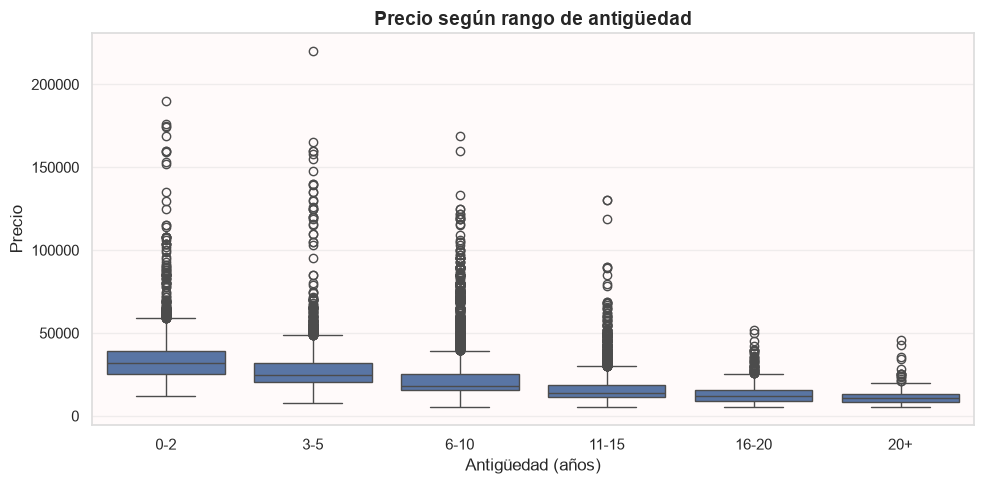

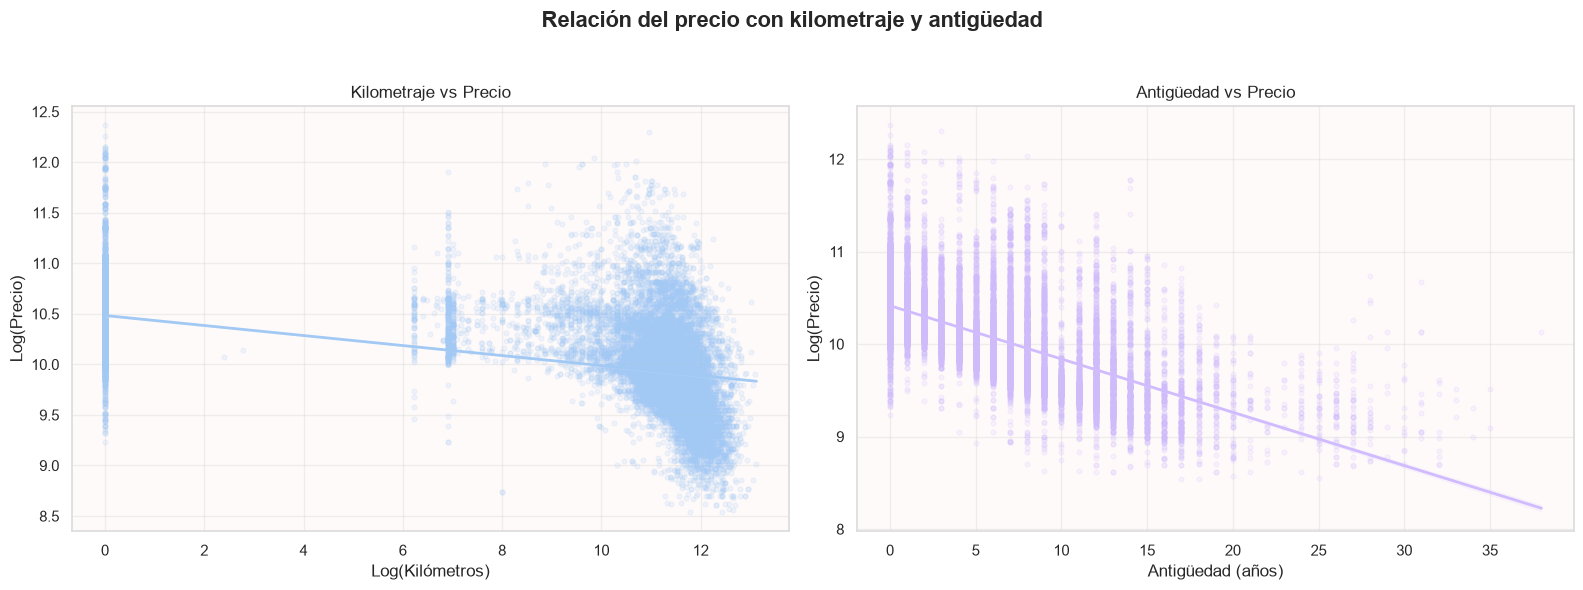

In [ ]:
data_visualizacion = pd.concat([X_train_final, X_val_final], ignore_index = True)
data_visualizacion = data_visualizacion[data_visualizacion["Antiguedad"] <= 50]
plot_precio_segun_rango_ant(data_visualizacion)
plot_precio_segun_antiguedad_km(data_visualizacion)

<p style="text-align: justify; text-justify: inter-word; font-size: 16px;">
Podemos observar, tanto para la <strong>antigüedad</strong> como para el <strong>kilometraje</strong> (plot presentado en la seccion <em>Visualizacion EDA hasta ahora</em>) una clara tendencia. El primer gráfico muestra que a mayor años de uso, el precio del vehículo (en escala logarítmica) decrece de manera consistente. Los autos de 0-2 años concentran los precios más altos, rondando entre los e^10 y e^12 USD, mientras que los de más de 20 años, se ubican en rangos más bajos.
</p>

<p style="text-align: justify; text-justify: inter-word; font-size: 16px;">
El segundo gráfico confirma lo esperado: a mayor log(Km), menor log(Precio). Los vehículos 0km tienen precios más elevados, lo cual es consistente con la realidad; y la dispersión aumenta a medida que sube el kilometraje, lo que genera el desgaste del vehículo, impactando negativamente en su precio.
</p>

<p style="text-align: justify; text-justify: inter-word; font-size: 16px;">
El boxplot por rangos de antiguedad refuerza ambas observaciones: la mediana de precio decae progresivamente, reduciéndose la dispersión en autos más antiguos. Los outliers más extremos se localizan en el rango de los 0-2 años, correspondiendo posiblemente, a vehículos de alta gama 0km.
</p>

<p style="text-align: justify; text-justify: inter-word; font-size: 16px;">
Con esto se deja en evidencia la importancia de ambos features en relación con el precio para la generalización del modelo predictivo a entrenar.
</p>

*¿Hay un ranking de colores de autos en cuanto a precio? ¿Cuál es el precio relativo de los distintos colores?*


In [ ]:
data_unificado = pd.concat([X_train, X_val]).reset_index(drop = True)

#Mediana para evitar que los otliers afecten
mediana_general = data_unificado['Precio'].median()

precio_por_color = data_unificado.groupby('Color')['Precio'].median().sort_values(ascending = False)
precio_relativo = ((precio_por_color - mediana_general) / mediana_general * 100).round(2)

display(pd.DataFrame({
    'Color': precio_por_color.index,
    'Mediana por color (USD)': precio_por_color.values,
    'Diferencia respecto a la mediana general': precio_relativo.values.round(2).astype(str) + '%'}))

,Color,Mediana por color (USD),Diferencia respecto a la mediana general
0,rosa,31803.837953,38.11%
1,amarillo,25031.982942,8.7%
2,gris,24800.000000,7.7%
3,azul,24307.036247,5.56%
4,blanco,23880.597015,3.7%
5,otro,22686.567164,-1.48%
6,bordó,21748.400853,-5.56%
7,plateado,21500.000000,-6.63%
8,negro,21321.961620,-7.41%
9,rojo,20042.643923,-12.96%


<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
Con esta tabla en consideracion, podemos ver que la existencia de un ranking de colores en cuanto a su precio es real. De esta forma, vehículos con colores menos frecuentes, tales como el <em>rosa</em> y el <em>amarillo</em> son los que presentan la mayor diferencia en cuanto a la mediana general de los precios. En el extremo opuesto, se tienen al <em>verde</em> y <em>dorado</em>, con una diferencia negativa, demostrando que sus precios estan porcentualmente debajo de los generales. Los colores mas comunes como el <em>gris</em>, <em>blanco</em> y <em>negro</em> se mantienen cercanos a la mediana general. Estas diferencias sugieren que el color está correlacionado con el segmento del vehículo: colores como el <em>rosa</em> y el <em>amarillo</em> tienden a aparecer en modelos deportivos o de lujo, mientras que colores atípicos como el <em>verde</em> 
se asocian a vehículos más antiguos o de menor valor de mercado.
</p>

*¿Es más barato comprar un auto a un privado o a una concesionaria/tienda? De ser así, ¿cuál es la diferencia % de precio?*


In [ ]:
#Mediana para evitar que los otliers afecten
mediana_por_vendedor = data_pre.groupby('Tipo de vendedor')['Precio'].median()
mediana_particulares = mediana_por_vendedor['particular']

valores = ((mediana_por_vendedor - mediana_particulares) / mediana_particulares * 100).round(2)

display(pd.DataFrame({
    'Tipo de vendedor': valores.index,
    'Diferencia respecto a particular': valores.values.round(2).astype(str) + '%'}))

,Tipo de vendedor,Diferencia respecto a particular
0,concesionaria,13.04%
1,particular,0.0%
2,tienda,43.89%


<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
Se definio la mediana de los precios de los vendedores particulares como la base para la comparacion, razon por la cual se tiene que su valor porcentual es del 0.0%. Los resultados muestran que tanto las concesionarias como las tiendas publican sus vehiculos a precios superiores, siendo estas ultimas las que mayor sobreprecio presentan respecto de los privados. Esto refleja como los costos adicionales que incluyen estos canales tales como garantias y/o tipos de financiacion, afectan sus precios de venta. Más coloquialmente, el precio propuesto por las tiendas es equivalente a la compra de 1 auto y práticamente la mitad de otro.
</p>

In [ ]:
#Definimos que las marcas con mas de 35 muestras sean las validas para calcular el Coeficiente de Variacion
marcas_validas = data_pre['Marca_Modelo'].str.split('_').str[0].value_counts()
marcas_validas = marcas_validas[marcas_validas >= 35].index
data_filtrado = data[data['Marca'].isin(marcas_validas)]

cv = data_filtrado.groupby('Marca')['Precio'].agg(['std', 'mean'])
cv["cv"] = cv["std"] / cv["mean"]
cv.sort_values("cv")

,std,mean,cv
Marca,,,
Fiat,1.080491e+07,2.331278e+07,0.463476
Citroën,1.144210e+07,2.086296e+07,0.548441
Volkswagen,1.755692e+07,2.845617e+07,0.616981
Peugeot,1.321951e+07,2.025624e+07,0.652614
Renault,1.039727e+07,1.523884e+07,0.682287
Chevrolet,1.501753e+07,2.181144e+07,0.688516
Nissan,1.503983e+07,2.145303e+07,0.701059
Chery,8.585606e+06,1.151105e+07,0.745858
Porsche,6.914162e+04,9.031488e+04,0.765562


*¿Hay alguna marca que tenga una menor dispersión en sus precios?*

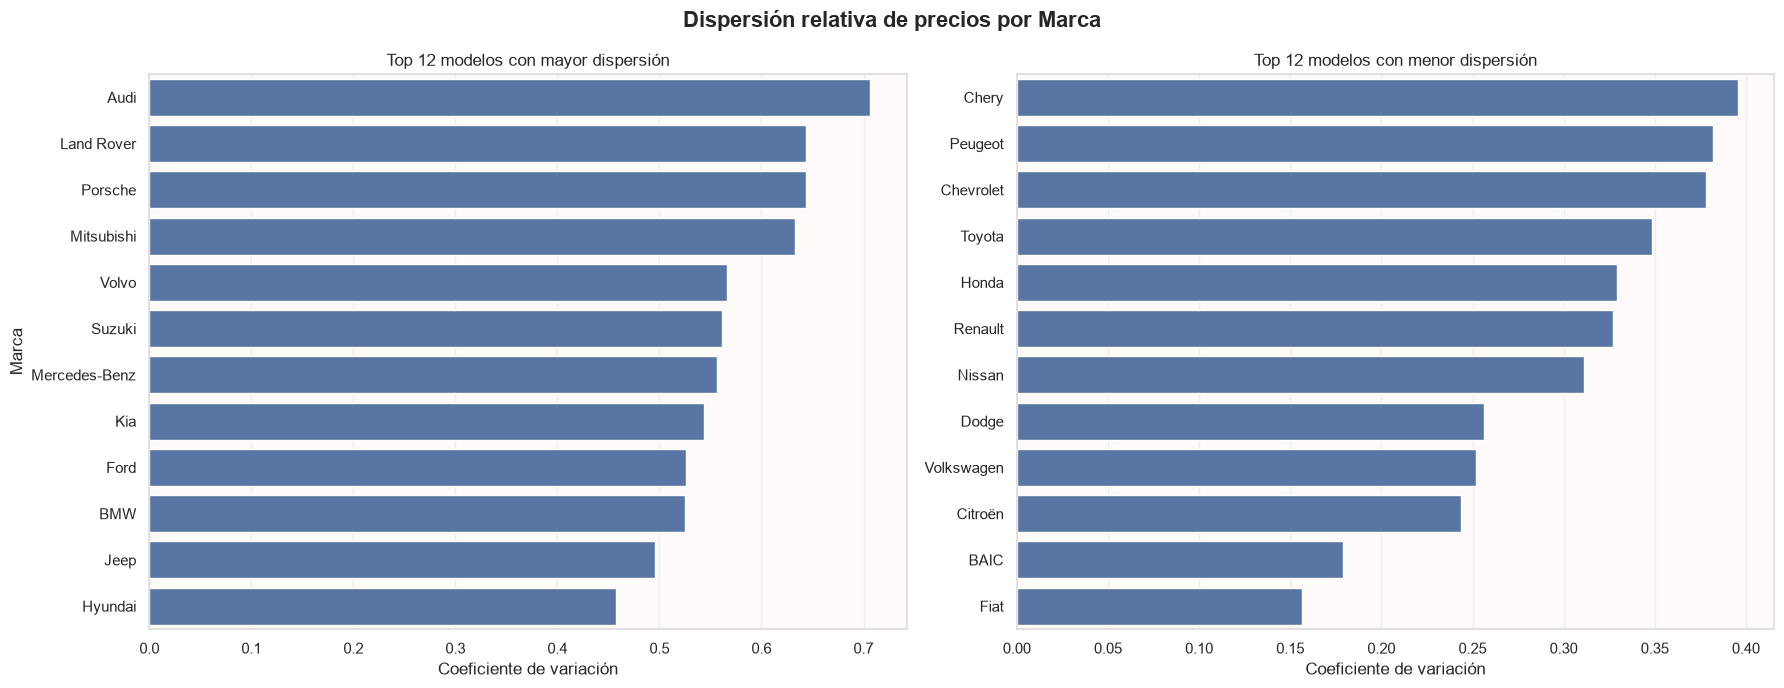

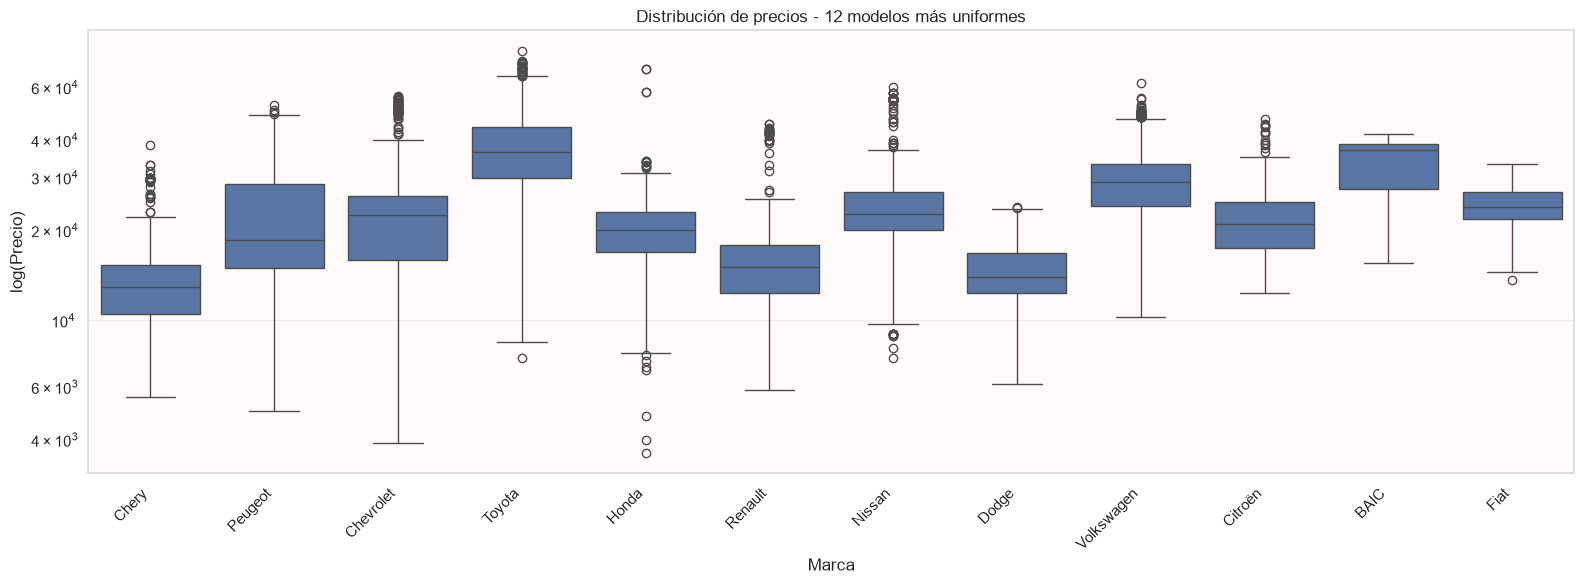

,count,mean,std,cv
Marca,,,,
Fiat,300,24093.087704,3768.593840,0.156418
BAIC,117,33450.802526,5986.260428,0.178957
Citroën,671,21435.038709,5221.010214,0.243574
Volkswagen,1895,29169.033212,7351.739242,0.252039
Dodge,179,14814.337554,3793.514545,0.256070
Nissan,983,23916.747183,7436.866998,0.310948
Renault,1379,15665.366450,5120.649378,0.326877
Honda,552,19877.425010,6545.851106,0.329311
Toyota,1215,37684.970950,13139.286677,0.348661


In [ ]:
data_pre_con_marca = data_pre.copy()
data_pre_con_marca['Marca'] = data['Marca']
data_pre_con_marca = data_pre_con_marca[data_pre_con_marca["Precio"] < 350000]

plot_dispersion_por_marca(data_pre_con_marca, target= "Precio", min_muestras= 35, top_n=12)

<p style="text-align: justify; text-justify: inter-word; font-size: 16px;">
Las marcas con mayor dispersión resultan ser <strong>Land Rover</strong>, <strong>Porsche</strong> y <strong>BMW</strong>, tres marcas de lujo, lo cual explica este resultado: ofrecen modelos que van desde vehículos de entrada hasta vehículos de alta gama, lo que genera una gran variabilidad de precios dentro de sus modelos. El boxplot confirma esto con cajas amplias (particularmente en el caso de Porsche) y outliers con valores extremos.
</p>

<p style="text-align: justify; text-justify: inter-word; font-size: 16px;">
En el extremo opuesto, encontramos a <strong>BAIC</strong>, <strong>Fiat</strong> y <strong>Citroën</strong>, que presentan la menor dispersión entre las marcas más predominantes del dataset. Se presentan como marcas con modelos más accesibles, los cuales se concentran en un rango de precio similar entre sí, y con un catálogo más acotado. Sus boxplots muestran cajas compactas y pocos outliers.
</p>
<p style="text-align: justify; text-justify: inter-word; font-size: 16px;">
Lo observado a partir de la información provista coincide con lo esperable para este tipo de marcas, donde se tienen tanto modelos exclusivos como de segmento medio.
</p>

### Comparación entre modelos

In [ ]:
resumen_final = pd.DataFrame({
    'Modelo': [
        'RL Base - Con TF-IDF',
        'RL Base - Sin TF-IDF',
        f'RL {mejor_rl_config["Modelo"]} (λ = {mejor_rl_config["Lambda"]}) - Con TF-IDF',
        f'RL {mejor_no_desc["Modelo"]} (λ = {mejor_no_desc["Lambda"]}) - Sin TF-IDF',
        'Red Neuronal - Con TF-IDF',
        'Red Neuronal - Sin TF-IDF',
        'XGBoost Categórico - Con TF-IDF',
        'XGBoost Categórico - Sin TF-IDF',
        'XGBoost OHE - Con TF-IDF',
        'XGBoost OHE - Sin TF-IDF',
    ],
    'RMSE (USD)': [
        rmse_rl_base, rmse_rl_base_no_desc,
        rmse_rl_final, rmse_rl_no_desc_final,
        resultados_nn.iloc[0]['RMSE'],
        resultados_nn_no_desc.iloc[0]['RMSE'],
        rmse_categorico_final, rmse_categorico_final_no_desc,
        rmse_ohe_final, rmse_ohe_final_no_desc
    ],
    'MAE (USD)': [
        mae_rl_base, mae_rl_base_no_desc,
        mae_rl_final, mae_rl_no_desc_final,
        resultados_nn.iloc[0]['MAE'],
        resultados_nn_no_desc.iloc[0]['MAE'],
        mae_categorico_final, mae_categorico_final_no_desc,
        mae_ohe_final, mae_ohe_final_no_desc
    ],
    'R²': [
        r2_rl_base, r2_rl_base_no_desc,
        r2_rl_final, r2_rl_no_desc_final,
        resultados_nn.iloc[0]['R2'],
        resultados_nn_no_desc.iloc[0]['R2'],
        r2_categorico_final, r2_categorico_final_no_desc,
        r2_ohe_final, r2_ohe_final_no_desc
    ]
}).sort_values('R²', ascending = False).reset_index(drop=True)

display(resumen_final)

### Modelo final